# 4. SELEX: antibacterial aptamers

This notebook demonstrates the use of clibas to analyze SELEX aptamer selections using data from Reischer and co-workers as an example.

For further details and the source of data, see [C. Kolm et al. DNA aptamers against bacterial cells can be efficiently selected by a SELEX process using state‑of‑the art qPCR and ultra‑deep sequencing. Sci. Rep. 2020, 10, 20917](https://www.nature.com/articles/s41598-020-77221-9)

In the paper, the authors conduct SELEX selections to identify DNA aptamere with specific affinity for live _Enterococcus faecalis_ cells. The authors conducted 11 rounds of selection using a simple DNA library containing a random 40±3 nt insert flanked by a 5'- (`TAGGGAAGAGAAGGACATATGAT`) and 3'-end (`TTGACTAGTACATGACCACTTGA`) constant regions. NGS data provided by the authors is in the paired-end read format. At present, paired-end read merging is not supported in clibas; prior to running this analysis, we have merged the reads separately using [FLASH](https://academic.oup.com/bioinformatics/article/27/21/2957/217265) with the following commands:

`--max-overlap=200` <br>
`--allow-outies` <br>
`--max-mismatch-density=0.10` <br>

The reads are provided with adapter sequences trimmed, so it is easy to write library designs:

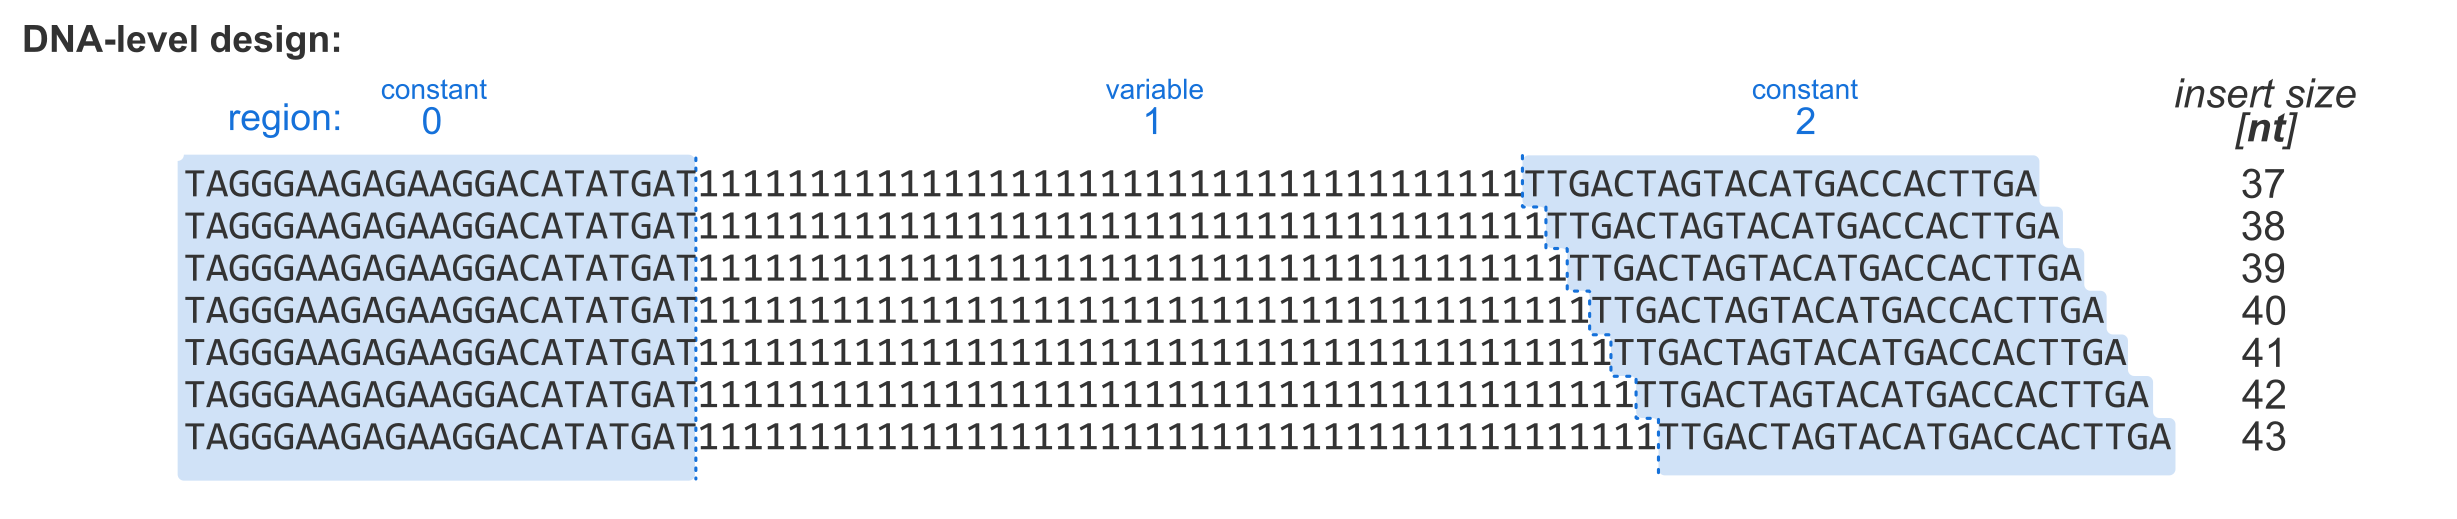

Naturally, there is no need for peptide library designs and a translation table in this case. The config file can be quite minimal:

```yaml
experiment: "Reischer_antibacterial_SELEX"

LibraryDesigns:
  dna_templates:
    - "TAGGGAAGAGAAGGACATATGAT1111111111111111111111111111111111111TTGACTAGTACATGACCACTTGA"
    - "TAGGGAAGAGAAGGACATATGAT11111111111111111111111111111111111111TTGACTAGTACATGACCACTTGA"
    - "TAGGGAAGAGAAGGACATATGAT111111111111111111111111111111111111111TTGACTAGTACATGACCACTTGA"
    - "TAGGGAAGAGAAGGACATATGAT1111111111111111111111111111111111111111TTGACTAGTACATGACCACTTGA"
    - "TAGGGAAGAGAAGGACATATGAT11111111111111111111111111111111111111111TTGACTAGTACATGACCACTTGA"
    - "TAGGGAAGAGAAGGACATATGAT111111111111111111111111111111111111111111TTGACTAGTACATGACCACTTGA"
    - "TAGGGAAGAGAAGGACATATGAT1111111111111111111111111111111111111111111TTGACTAGTACATGACCACTTGA"
    
  dna_monomers:
    1: ["A", "G", "T", "C"] #N
    
TrackerConfig:
  logs: "./outputs/Reischer_SELEX"                 # Directory for writing logs to
  parser_out: "./outputs/Reischer_SELEX"           # Directory that stores fastq parser outputs
  analysis_out: "./outputs/Reischer_SELEX"         # Directory that stores outputs of data analysis operations
  
LoggerConfig:
  verbose: false                    # Verbose loggers print to the console
  log_to_file: true                 # Write logs to file
  level: "INFO"                     # Logger level; accepted values: "DEBUG", "INFO", "WARNING", "ERROR"
```

By way of illustration, we will silence the logger for this example, and instead write logs to a file – see the `LoggerConfig` specifications above. 

In [1]:
import clibas as C
C.initialize(config_path='Reischer_antibacterial_SELEX_config.yaml')

This paper by Reischer is one of the few examples that we could find that details NGS data processing. 
Below, we build a pipeline that roughly reproduces what is described in the paper. The authors mention the following two filtering steps:

> An error rate of 20% (≤ 4 nt mismatches) within the constant regions was allowed; Sequences not fulfilling these conditions were discarded

and 

> Next, fastp 0.20.0 was used to filter sequences by quality score, discarding all sequences of an overall Phred quality score ≤ 30

The pipeline below is intentionally minimal – we are not collecting any optional stats, just trying to reproduce the paper:

In [3]:
C.pipeline.enque(
    
[
    # discard the DNA of incorrect length (incompatible with library designs)
    C.fastq_parser.len_filter(where='dna'),
    
    # discard the DNA with incorrect/overly mutated constant regions
    # up to 4 mutations are tolerated in a single region; 
    # this can be achieved by calling cr_filter twice:
    C.fastq_parser.cr_filter(where='dna', loc=[0], tol=4),
    C.fastq_parser.cr_filter(where='dna', loc=[2], tol=4), 
    
    # discard the DNA with average Q scores below 30 in region 1 (random insert region)
    C.fastq_parser.q_score_filt(minQ=30, loc=[1]),
    
    # clip DNA sequences to region 1 (random insert region)
    C.fastq_parser.fetch_at(where='dna', loc=[1]),
    
    # discard all DNA containing any ambiguous bases (N, etc)
    C.fastq_parser.filt_ambiguous(where='dna'),

    # count retained DNA sequences
    C.fastq_parser.count_summary(where='dna', top_n=1000, fmt='csv')
]
)

In [4]:
'''run everything from the specified folder together in memory'''
loader = C.data_loader.fetch_gz_from_dir(data_dir='./sequencing_data/Reischer_bacterial_SELEX')
data = C.pipeline.load_and_run(loader=loader, save_summary=True)

The minimal pipeline above demonstrates how full analysis can be performed with essentially just 7 operations and a few lines of code.
Without collecting optional statistics, the pipeline is fast. It took 31.5 s to process all 11 .fastq.gz files:

In [8]:
from pathlib import Path
import pandas as pd

out_dir = C.fastq_parser.dirs.parser_out
exp_name = C.fastq_parser.exp_name

fname = next(Path(out_dir).glob(f"{exp_name}_pipeline_summary*.csv"))
summary = pd.read_csv(fname)

t = summary['elapsed time, s'].sum()
print(f'The run was completed in {t:.1f} s!')

The run was completed in 31.5 s!


In [25]:
c = [x for x in summary.columns if x.startswith('Reischer')]
reads = int(summary.iloc[1][c].sum())
print(f'The initial dataset had {reads:.2e} reads across 11 samples (.fastq files)')

The initial dataset had 2.54e+06 reads across 11 samples (.fastq files)


Most importantly, we arrive at the same top sequences as the authors:

In [32]:
out_dir = C.fastq_parser.dirs.parser_out
sample_name = "Reischer_bact_SELEX_r11"

f_dir = Path(out_dir) / sample_name
fname = next(Path(f_dir).glob(f"{sample_name}_dna_count_summary*.csv"))

df = pd.read_csv(fname)
df.head(20).style.set_table_styles(
    [{'selector': 'th, td', 'props': [('font-family', 'Consolas, monospace')]}]
)

,Index,DNA,dna count,Dataset %
0,1,TTTCTCAACGGGACCATCACTTACCTCAAGTACTTGGACG,2771,1.405793
1,2,GTCAACTCATTTATGGTGCTCCTCGTACCTCAGGTGGTTA,475,0.240979
2,3,CCGGCTATCTCCCTACCGTGGCCGAGTACCTCAAACGTTT,456,0.231339
3,4,GGCTCTCTGGTCTTCAAGGCCCATGATTACAGTCAGATCA,345,0.175027
4,5,CTGCCTGACTTCATAATGCTTCTTCTCCCTGTGGTACTTG,321,0.162851
5,6,CCTTAGGTCTTAACTATCAGGCGGTCTGTATCAATTCGAT,294,0.149153
6,7,GGCAGGGAGCGACCGGGTCATTGATTATCTGTCAAAGTGT,293,0.148646
7,8,GGCCATACCTCGTGCCTTCTGTGATCATCTCTATCAATTG,271,0.137485
8,9,CTCAATCATCAAGGGTCTACTTCCCGCTTGTGGGCCATTC,263,0.133426
9,10,CCTCTCTCTTACTGCTACTGGGCAGGGTACTCAATTACGT,251,0.127338


During processing, we truncated the reads to show only the variable region (`C.fastq_parser.fetch_at(where='dna', loc=[1])`), but these results are broadly consistent with the paper: top-1, 2, 3, 8, 10, 11 and 12 are the same (see the snippet from the paper below):

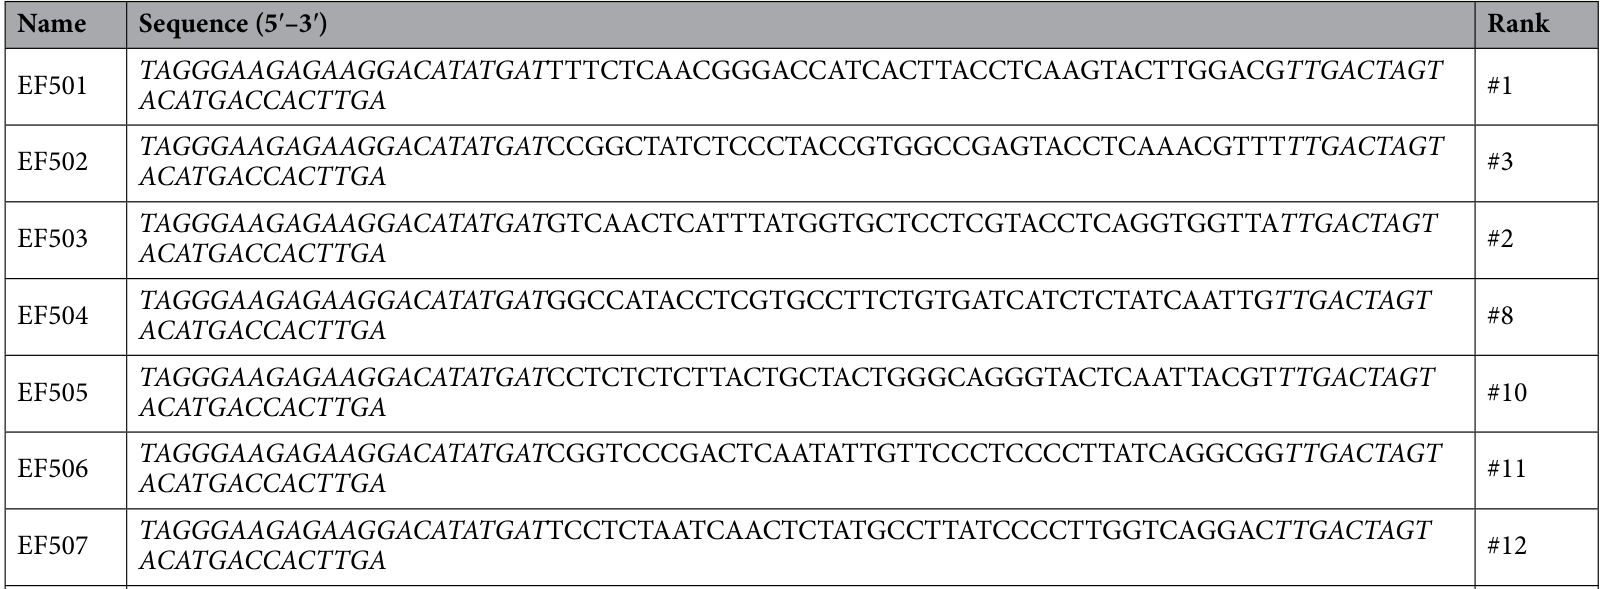